In [3]:
import torch
model = torch.hub.load('facebookresearch/deit:main', 'deit_tiny_patch16_224', pretrained=True)


Using cache found in /home/system/.cache/torch/hub/facebookresearch_deit_main


In [4]:
for block in model.blocks:
  block.attn.fused_attn = False

In [40]:
from transformers import AutoImageProcessor, AutoModel
import torch
dino = AutoModel.from_pretrained('facebook/dinov2-large')

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

In [41]:
import cv2
# img = cv2.imread("/media/system/ZERBUIS_EXT_STOR/dynamic_slam/datasets/our_office_static/image_1771496650929.png")
img = cv2.imread('bird.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img_np = img.copy()
img = torch.from_numpy(img)
img = img.permute(-1, 0, 1).unsqueeze(0)
img.shape

torch.Size([1, 3, 224, 224])

In [42]:
output = dino(img)

In [43]:
from icecream import ic
ic(output.last_hidden_state.shape, output.pooler_output.shape)

class_token = output.last_hidden_state[:, 0, :]

ic| output.last_hidden_state.shape: torch.Size([1, 257, 1024])
    output.pooler_output.shape: torch.Size([1, 1024])


In [49]:
feat = output.last_hidden_state
cls = feat[:, 0:1, :]            # (1, 1, D)
patch = feat[:, 1:, :]           # (1, P, D)

# cosine similarity
sim = torch.nn.functional.cosine_similarity(patch, cls, dim=-1)
# shape: (1, P)

sim = sim.squeeze(0)

num_patches = sim.shape[0]
h = w = int(num_patches ** 0.5)

sim_map = sim.reshape(h, w)
sim_map = (sim_map - sim_map.min()) / (sim_map.max() - sim_map.min())

import torch.nn.functional as F
ic(sim_map.shape)
sim_map = sim_map.unsqueeze(0).unsqueeze(0)
sim_map = F.interpolate(sim_map, (224, 224), mode='bilinear', align_corners=False)
sim_map = sim_map.squeeze()
import numpy as np
sim_map = np.array(sim_map.detach().cpu())

ic| sim_map.shape: torch.Size([16, 16])


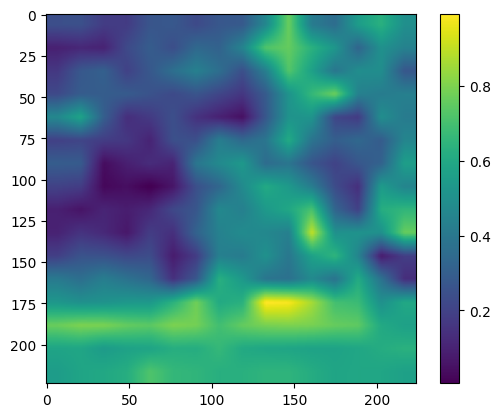

In [52]:
import matplotlib.pyplot as plt

plt.imshow(sim_map)
plt.colorbar()

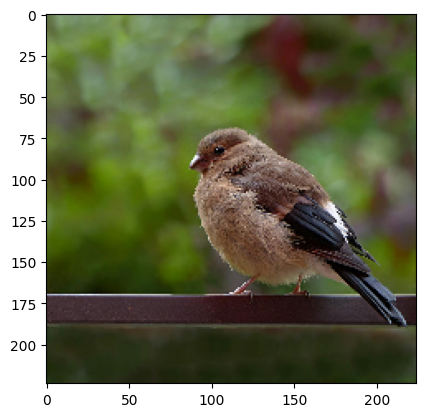

In [51]:
plt.imshow(img_np)

In [1]:
import os
import os.path as osp

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
import cv2
import torch
import torchvision.transforms as T

In [2]:

img_size = 224
dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2_vits14 = dinov2_vits14
dinov2_vits14.eval()

transform = T.Compose([
                T.ToTensor(), 
                T.Resize(img_size+int(img_size*0.01)*10), 
                T.CenterCrop(img_size), 
                T.Normalize([0.5], [0.5]), 
            ])


patch_h = patch_w = img_size // 14

start_idx = 1
end_idx = 4
img_cnt = end_idx-start_idx+1

Using cache found in /home/system/.cache/torch/hub/facebookresearch_dinov2_main
/home/system/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/system/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/system/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [3]:
img = cv2.imread('/media/system/ZERBUIS_EXT_STOR/dynamic_slam/src/image.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
img = cv2.resize(img, (224, 224))
img_np = img.copy()
img = torch.from_numpy(img)
img = img.permute(-1, 0, 1).unsqueeze(0)
img = img.float()

embeddings = dinov2_vits14.forward_features(img)
feat = embeddings['x_norm_patchtokens']
feat = feat.squeeze(0)                  # (256, D)
feat_np = feat.detach().cpu().numpy()

(222, 351, 3)


In [4]:
feat.shape, patch_h

(torch.Size([256, 384]), 16)

In [5]:
feat_reshaped = feat.reshape(1, patch_w, patch_h, -1)
feat_reshaped.shape

torch.Size([1, 16, 16, 384])

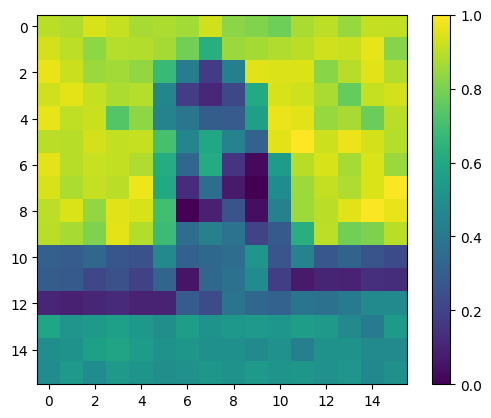

In [6]:
pca = PCA(n_components=1)
pca_feat = pca.fit_transform(feat_np)   # (256, 3)

pca_feat = minmax_scale(pca_feat)
pca_feat = pca_feat.reshape(patch_h, patch_w)

plt.imshow(pca_feat)
plt.colorbar()
plt.show()

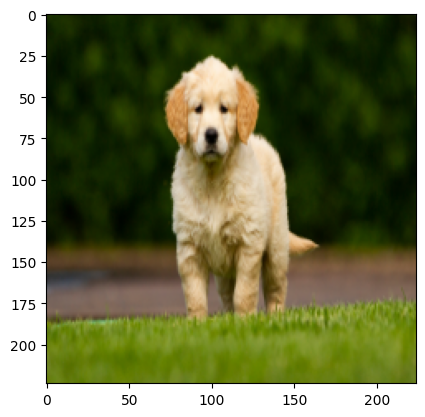

In [7]:
plt.imshow(img_np)